# Question 21: Does service-break frequency increase or decrease in later tournament rounds? 

Using `tennis_power`, `round`

In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
MINI_PROJECT_ROOT = Path.cwd().parents[2]

DATA_ROOT = (
    MINI_PROJECT_ROOT
    / "Tennis Schema"
    / "tennis_data"
)

PROCESSED_ROOT = DATA_ROOT / "processed"

TEAM_DATA_ROOT = DATA_ROOT / "Data"

In [4]:
tennis_power = pd.read_parquet(PROCESSED_ROOT / "tennis_power_clean.parquet")
round_data = pd.read_parquet(PROCESSED_ROOT / "round_clean.parquet")

print("Tennis power columns:")
print(tennis_power.columns.tolist())

print("\nRound columns:")
print(round_data.columns.tolist())

print("\nTennis power shape:", tennis_power.shape)
print("Round shape:", round_data.shape)

Tennis power columns:
['match_id', 'set_num', 'game_num', 'value', 'break_occurred', 'snapshot_date']

Round columns:
['match_id', 'round_id', 'name', 'slug', 'cup_round_type', 'snapshot_date']

Tennis power shape: (469677, 6)
Round shape: (19283, 6)


In [5]:
# Inspect tournament rounds and service-break values

print("Tournament rounds:")
print(round_data["name"].value_counts(dropna=False))

print("\nBreak occurred:")
print(tennis_power["break_occurred"].value_counts(dropna=False))

Tournament rounds:
name
Round of 32              8395
Round of 16              4423
Quarterfinal             2197
Qualification round 1    1770
Semifinal                1102
Final                     539
Round of 64               444
Round of 128              266
Qualification round 2     147
Name: count, dtype: int64

Break occurred:
break_occurred
False    311980
True     157697
Name: count, dtype: int64


In [ ]:
# Keep the latest record for each game and match round

power_final = (tennis_power.sort_values(
    ["match_id", "set_num", "game_num", "snapshot_date"]).drop_duplicates(subset=["match_id", "set_num", "game_num"], keep="last"))

round_final = (round_data.sort_values(["match_id", "snapshot_date"]).drop_duplicates(subset="match_id", keep="last")) # to determin the game belongs to which round

print("Unique games:", len(power_final))
print("Unique match rounds:", len(round_final))

Unique games: 230581
Unique match rounds: 9243


In [7]:
# Add tournament round information to each game

power_with_round = power_final.merge(round_final[["match_id", "name"]], on="match_id", how="inner")

power_with_round = power_with_round.rename(columns={"name": "round_name"})

print("Games available for analysis:", len(power_with_round))

power_with_round[["match_id", "set_num", "game_num", "break_occurred", "round_name"]].head()

Games available for analysis: 182039


,match_id,set_num,game_num,break_occurred,round_name
0,11998445,1,1,False,Round of 16
1,11998445,1,2,False,Round of 16
2,11998445,1,3,False,Round of 16
3,11998445,1,4,False,Round of 16
4,11998445,1,5,True,Round of 16


In [9]:
# Calculate service-break percentage by tournament round

break_stats = (power_with_round.groupby("round_name").agg(total_games=("break_occurred", "size"), service_breaks=("break_occurred", "sum")))

break_stats["break_percentage"] = (break_stats["service_breaks"] / break_stats["total_games"] * 100)

break_stats.sort_values("break_percentage", ascending=False)

,total_games,service_breaks,break_percentage
round_name,,,
Final,5405,1933,35.763182
Semifinal,11151,3802,34.095597
Quarterfinal,21848,7351,33.646100
Round of 64,4254,1400,32.910202
Round of 16,42850,14066,32.826138
Round of 32,78074,25553,32.729206
Qualification round 1,14696,4800,32.661949
Qualification round 2,1095,329,30.045662
Round of 128,2666,756,28.357089


In [ ]:
# Order the tournament rounds chronologically

round_order = ["Qualification round 1", "Qualification round 2", "Round of 128", "Round of 64", "Round of 32", "Round of 16", "Quarterfinal", "Semifinal", "Final"]

break_stats = break_stats.reindex(round_order)

break_stats

,total_games,service_breaks,break_percentage
round_name,,,
Qualification round 1,14696,4800,32.661949
Qualification round 2,1095,329,30.045662
Round of 128,2666,756,28.357089
Round of 64,4254,1400,32.910202
Round of 32,78074,25553,32.729206
Round of 16,42850,14066,32.826138
Quarterfinal,21848,7351,33.646100
Semifinal,11151,3802,34.095597
Final,5405,1933,35.763182


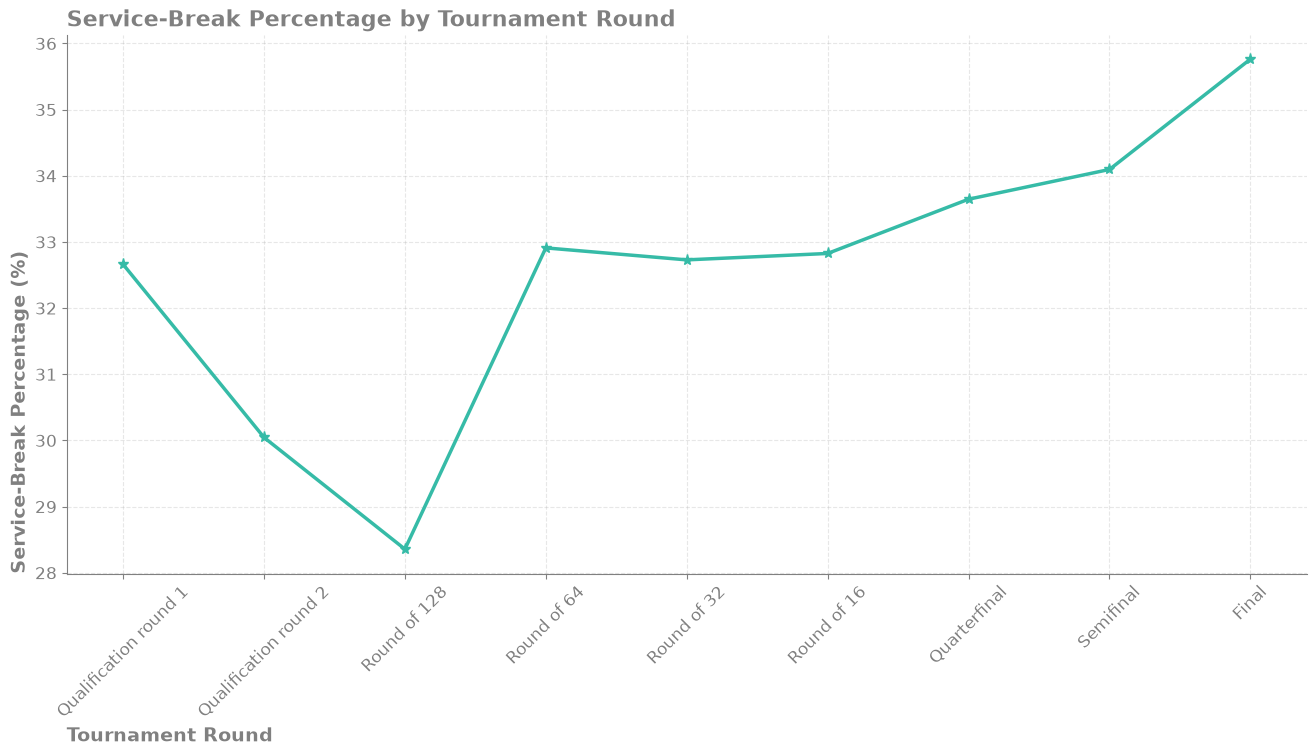

In [24]:
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(
    break_stats.index,
    break_stats["break_percentage"],
    marker="*",
    markersize=8,
    linewidth=2.5,
    color="#36BBA7")

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

ax.set_title("Service-Break Percentage by Tournament Round", loc="left", weight="bold", color="gray", fontsize=16)
ax.set_xlabel("Tournament Round", loc="left", weight="bold", color="gray", fontsize=14)
ax.set_ylabel("Service-Break Percentage (%)", loc="bottom", weight="bold", color="gray", fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize="large", rotation=45)
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.set_axisbelow(True)
ax.grid(linestyle="--", alpha=0.3)

plt.show()

Service-break percentage generally increases in the later stages of the tournament, although the pattern is not strictly increasing across every round. The percentage rises from 33.6% in the quarterfinals to 34.1% in the semifinals and reaches its highest level, 35.8%, in the final. This suggests that service breaks were somewhat more frequent in the later tournament rounds in this dataset.